# Загрузка данных RuCoLA и разбиение in_domain_train на train/val.

In [8]:
import os
import sys
import warnings
import logging

os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

logging.getLogger("transformers").setLevel(logging.CRITICAL)
logging.getLogger("transformers.modeling_utils").setLevel(logging.CRITICAL)
logging.getLogger("transformers.configuration_utils").setLevel(logging.CRITICAL)
logging.getLogger("transformers.tokenization_utils").setLevel(logging.CRITICAL)
logging.getLogger("transformers.generation").setLevel(logging.CRITICAL)
logging.getLogger("datasets").setLevel(logging.CRITICAL)
logging.getLogger("huggingface_hub").setLevel(logging.CRITICAL)
logging.getLogger("filelock").setLevel(logging.CRITICAL)

import transformers
transformers.logging.disable_default_handler()
transformers.logging.set_verbosity_error()
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, matthews_corrcoef, classification_report
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
import random
from transformers import (
    GPT2LMHeadModel, 
    GPT2Tokenizer,
    T5Tokenizer,
    T5ForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)

In [4]:
# Загрузка данных
train_df = pd.read_csv("in_domain_train.csv")
dev_df   = pd.read_csv("in_domain_dev.csv")
print(f"Загружено из CSV: train={len(train_df)}, dev={len(dev_df)}")

# Разбиение train на train/val (80/20)
train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["acceptable"]
)

print(f"\n Распределение после разбиения:")
print(f"  train : {len(train_split)} (acceptable: {train_split['acceptable'].sum()}, "
      f"unacceptable: {(1 - train_split['acceptable']).sum()})")
print(f"  val   : {len(val_split)} (acceptable: {val_split['acceptable'].sum()}, "
      f"unacceptable: {(1 - val_split['acceptable']).sum()})")
print(f"  test  : {len(dev_df)} (in_domain_dev)")

# Сохранение
os.makedirs("data/splits", exist_ok=True)
train_split.to_csv("data/splits/train.csv", index=False)
val_split.to_csv("data/splits/val.csv", index=False)
dev_df.to_csv("data/splits/test.csv", index=False)

print("\n Файлы сохранены в data/splits/")
print(train_split.head())

Загружено из CSV: train=7869, dev=983

 Распределение после разбиения:
  train : 6295 (acceptable: 4691, unacceptable: 1604)
  val   : 1574 (acceptable: 1173, unacceptable: 401)
  test  : 983 (in_domain_dev)

 Файлы сохранены в data/splits/
        id                                           sentence  acceptable  \
1148  1148  К сожалению, никакого практического значения т...           1   
1891  1891  Как создавался "Подросток" и "Братья Карамазовы"?           1   
7477  7477        Он сидел у печки и подбрасывал в нее дрова.           1   
6581  6581     У вас не горел свет, и я решил, что вы уехали.           1   
3673  3673  Чтобы получить живительный заряд положительной...           1   

     error_type detailed_source  
1148          0            USE5  
1891          0   Paducheva2010  
7477          0    Seliverstova  
6581          0   Paducheva2004  
3673          0            USE5  


# Fine-tuning RuBERT-base на задаче RuCoLA

In [5]:
# Параметры
MODEL_NAME = "sberbank-ai/ruBert-base"
BATCH_SIZE = 16
EPOCHS = 5
LR = 3e-5
MAX_LENGTH = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загрузка данных
train_df = pd.read_csv("data/splits/train.csv")
val_df   = pd.read_csv("data/splits/val.csv")
test_df  = pd.read_csv("data/splits/test.csv")

train_dataset = Dataset.from_pandas(train_df[["sentence", "acceptable"]])
val_dataset   = Dataset.from_pandas(val_df[["sentence", "acceptable"]])
test_dataset  = Dataset.from_pandas(test_df[["sentence", "acceptable"]])

# Токенизатор и модель
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    problem_type="single_label_classification"
)

def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        truncation=True,
        padding=False,       # паддинг сделает data_collator
        max_length=MAX_LENGTH
    )

train_encoded = train_dataset.map(tokenize_function, batched=True)
val_encoded   = val_dataset.map(tokenize_function, batched=True)
test_encoded  = test_dataset.map(tokenize_function, batched=True)

train_encoded = train_encoded.rename_column("acceptable", "label")
val_encoded   = val_encoded.rename_column("acceptable", "label")
test_encoded  = test_encoded.rename_column("acceptable", "label")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Метрики
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    mcc = matthews_corrcoef(labels, preds)
    return {"accuracy": acc, "mcc": mcc}

# Training Arguments
training_args = TrainingArguments(
    output_dir="./results/rubert_finetuned",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="mcc",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encoded,
    eval_dataset=val_encoded,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("\n Начинаем обучение RuBERT...")
trainer.train()

print("\n Оценка на validation set:")
val_results = trainer.evaluate(eval_dataset=val_encoded)
print(val_results)

print("\n Оценка на test set (in_domain_dev):")
test_results = trainer.evaluate(eval_dataset=test_encoded)
print(test_results)

predictions = trainer.predict(test_encoded)
preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

print("\n Classification Report (test):")
print(classification_report(labels, preds, target_names=["unacceptable (0)", "acceptable (1)"]))

# ── Сохранение модели ────────────────────────────────────────
trainer.save_model("./results/rubert_finetuned_best")
tokenizer.save_pretrained("./results/rubert_finetuned_best")
print("\n Модель сохранена в ./results/rubert_finetuned_best")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

Map:   0%|          | 0/6295 [00:00<?, ? examples/s]

Map:   0%|          | 0/1574 [00:00<?, ? examples/s]

Map:   0%|          | 0/983 [00:00<?, ? examples/s]

...

{'eval_loss': 1.1717451810836792, 'eval_accuracy': 0.7955239064089522, 'eval_mcc': 0.39906351084415215}


/Users/zenyuk.k.s/.conda/envs/otus_ml/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



 Classification Report (test):
                  precision    recall  f1-score   support

unacceptable (0)       0.66      0.40      0.50       250
  acceptable (1)       0.82      0.93      0.87       733

        accuracy                           0.80       983
       macro avg       0.74      0.67      0.69       983
    weighted avg       0.78      0.80      0.78       983



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Модель сохранена в ./results/rubert_finetuned_best


# Решение задачи RuCoLA с помощью RuGPT3 в режиме few-shot / zero-shot

Загрузка модели ai-forever/rugpt3large_based_on_gpt2...


Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: ai-forever/rugpt3large_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Prompt: prompt_1_binary | Few-shot: 0
  Обработано 50/200...
  Обработано 100/200...
  Обработано 150/200...
  Обработано 200/200...
  Accuracy: 0.6700
  MCC:      -0.0838

Prompt: prompt_1_binary | Few-shot: 1
  Обработано 50/200...
  Обработано 100/200...
  Обработано 150/200...
  Обработано 200/200...
  Accuracy: 0.6350
  MCC:      -0.1010

Prompt: prompt_1_binary | Few-shot: 2
  Обработано 50/200...
  Обработано 100/200...
  Обработано 150/200...
  Обработано 200/200...
  Accuracy: 0.4050
  MCC:      -0.0628

Prompt: prompt_1_binary | Few-shot: 4
  Обработано 50/200...
  Обработано 100/200...
  Обработано 150/200...
  Обработано 200/200...
  Accuracy: 0.3950
  MCC:      0.0684

Prompt: prompt_2_label | Few-shot: 0
  Обработано 50/200...
  Обработано 100/200...
  Обработано 150/200...
  Обработано 200/200...
  Accuracy: 0.7150
  MCC:      -0.0442

Prompt: prompt_2_label | Few-shot: 1
  Обработано 50/200...
  Обработано 100/200...
  Обработано 150/200...
  Обработано 200/200...
  Ac

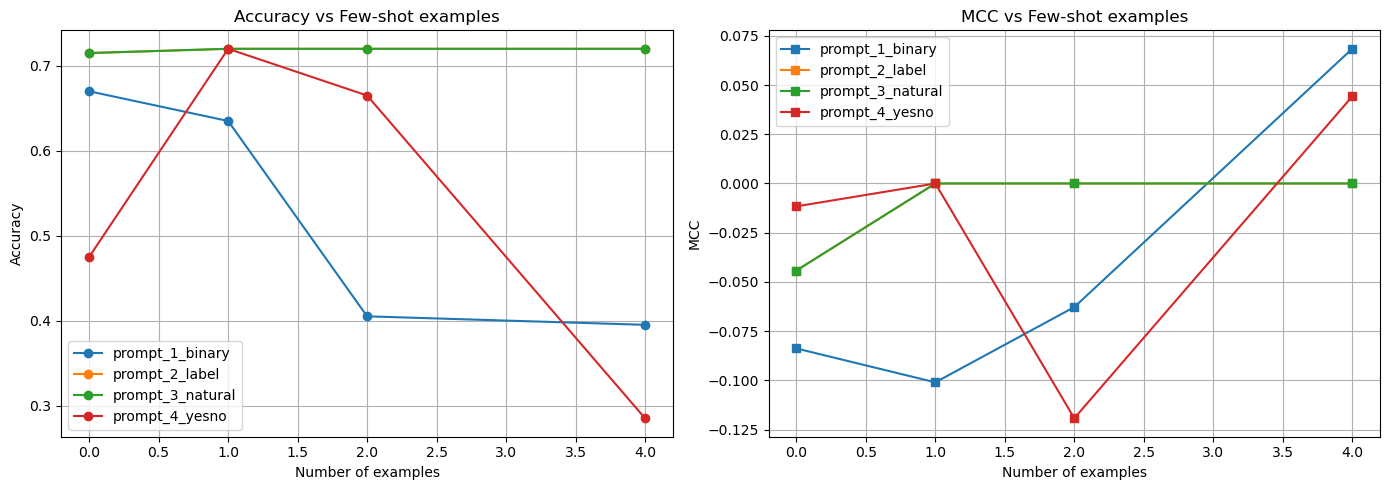

In [3]:
# Параметры
MODEL_NAME = "ai-forever/rugpt3large_based_on_gpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загрузка данных
train_df = pd.read_csv("data/splits/train.csv")
val_df   = pd.read_csv("data/splits/val.csv")
test_df  = pd.read_csv("data/splits/test.csv")

# Загрузка модели и токенизатора
print(f"Загрузка модели {MODEL_NAME}...")
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME, clean_up_tokenization_spaces=False)
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

# Варианты промптов
PROMPTS = {
    "prompt_1_binary": (
        "Определи, является ли предложение грамматически корректным.\n"
        "Ответь только 'да' или 'нет'.\n"
        "Предложение: {sentence}\n"
        "Ответ:"
    ),
    "prompt_2_label": (
        "Приемлемость предложения (1 — приемлемо, 0 — неприемлемо):\n"
        "Предложение: {sentence}\n"
        "Приемлемость:"
    ),
    "prompt_3_natural": (
        "Грамматически правильное предложение или нет?\n"
        "Предложение: {sentence}\n"
        "Это предложение грамматически:"
    ),
    "prompt_4_yesno": (
        "Проверь предложение на грамматические ошибки.\n"
        "Предложение: {sentence}\n"
        "Есть ли ошибки? Ответ (да/нет):"
    ),
}

# Функция генерации ответа
def generate_answer(prompt_text, max_new_tokens=10):
    """Генерация ответа модели на промпт."""
    inputs = tokenizer(prompt_text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,       
            do_sample=False,     
            pad_token_id=tokenizer.eos_token_id,
            num_beams=1,
        )
    
    # Декодируем только новые токены
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    text = tokenizer.decode(generated, skip_special_tokens=True)
    return text.strip()


def parse_answer(text):
    text_lower = text.lower().strip()
    
    # Положительные маркеры
    positive_markers = ["да", "1", "приемлем", "правильн", "корректн", "верн", "yes"]
    # Отрицательные маркеры
    negative_markers = ["нет", "0", "неприемлем", "неправильн", "ошибк", "некорректн", "no"]
    
    for marker in positive_markers:
        if marker in text_lower:
            return 1
    for marker in negative_markers:
        if marker in text_lower:
            return 0
    return 1


def get_few_shot_examples(train_df, n_examples, seed=42):
    rng = random.Random(seed)
    
    pos_examples = train_df[train_df["acceptable"] == 1].sample(
        n=min(n_examples // 2 + n_examples % 2, len(train_df[train_df["acceptable"] == 1])),
        random_state=seed
    )
    neg_examples = train_df[train_df["acceptable"] == 0].sample(
        n=min(n_examples // 2, len(train_df[train_df["acceptable"] == 0])),
        random_state=seed
    )
    
    examples = pd.concat([pos_examples, neg_examples]).head(n_examples)
    return examples


def build_few_shot_prompt(sentence, examples_df, prompt_template, label_format="да/нет"):
    context = ""
    for _, row in examples_df.iterrows():
        example_prompt = prompt_template.format(sentence=row["sentence"])
        label = "да" if row["acceptable"] == 1 else "нет"
        context += example_prompt + f" {label}\n\n"
    target_prompt = prompt_template.format(sentence=sentence)
    return context + target_prompt


# перебор prompts × few-shot counts
N_SHOT_VALUES = [0, 1, 2, 4]  # 0 = zero-shot
MAX_TEST_SAMPLES = 200
test_sample = test_df.sample(n=min(MAX_TEST_SAMPLES, len(test_df)), random_state=42)

results = []

for prompt_name, prompt_template in PROMPTS.items():
    for n_shot in N_SHOT_VALUES:
        print(f"\n{'='*60}")
        print(f"Prompt: {prompt_name} | Few-shot: {n_shot}")
        print(f"{'='*60}")
        
        # Получаем few-shot примеры
        if n_shot > 0:
            examples_df = get_few_shot_examples(train_df, n_shot)
        else:
            examples_df = pd.DataFrame()
        
        predictions = []
        true_labels = []
        
        for idx, row in test_sample.iterrows():
            sentence = row["sentence"]
            true_label = row["acceptable"]
            
            # Формируем промпт
            if n_shot > 0:
                full_prompt = build_few_shot_prompt(
                    sentence, examples_df, prompt_template
                )
            else:
                full_prompt = prompt_template.format(sentence=sentence)
            
            # Генерация ответа
            raw_answer = generate_answer(full_prompt)
            pred_label = parse_answer(raw_answer)
            
            predictions.append(pred_label)
            true_labels.append(true_label)
            
            if len(predictions) % 50 == 0:
                print(f"  Обработано {len(predictions)}/{len(test_sample)}...")
        
        # Метрики
        acc = accuracy_score(true_labels, predictions)
        mcc = matthews_corrcoef(true_labels, predictions)
        
        print(f"  Accuracy: {acc:.4f}")
        print(f"  MCC:      {mcc:.4f}")
        
        results.append({
            "prompt": prompt_name,
            "n_shot": n_shot,
            "accuracy": acc,
            "mcc": mcc,
        })

# Сводная таблица результатов
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ RuGPT3")
print("="*60)
print(results_df.to_string(index=False))
results_df.to_csv("results/gpt3_fewshot_results.csv", index=False)
print("\nРезультаты сохранены в results/gpt3_fewshot_results.csv")

# Визуализация
try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for prompt_name in PROMPTS.keys():
        subset = results_df[results_df["prompt"] == prompt_name]
        axes[0].plot(subset["n_shot"], subset["accuracy"], marker="o", label=prompt_name)
        axes[1].plot(subset["n_shot"], subset["mcc"], marker="s", label=prompt_name)
    
    axes[0].set_title("Accuracy vs Few-shot examples")
    axes[0].set_xlabel("Number of examples")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].set_title("MCC vs Few-shot examples")
    axes[1].set_xlabel("Number of examples")
    axes[1].set_ylabel("MCC")
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig("results/gpt3_fewshot_plot.png", dpi=150)
    print("График сохранён: results/gpt3_fewshot_plot.png")
except ImportError:
    print("matplotlib не установлен, пропускаем визуализацию")

# Fine-tuning RuT5 на задаче RuCoLA

In [9]:
# Параметры
MODEL_NAME = "sberbank-ai/ruT5-base"
BATCH_SIZE = 16
EPOCHS = 2
LR = 1e-4
MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 8

POS_LABEL = "yes"
NEG_LABEL = "no"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загрузка данных
train_df = pd.read_csv("data/splits/train.csv")
val_df   = pd.read_csv("data/splits/val.csv")
test_df  = pd.read_csv("data/splits/test.csv")

# Токенизатор и модель
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

# Препроцессинг
def preprocess_function(examples):
    """
    Токенизирует предложения и создаёт target-последовательности.
    Для T5: вход = предложение, выход = "yes" или "no".
    """
    # Вход: префикс + предложение
    inputs = ["Проверь приемлемость: " + s for s in examples["sentence"]]
    
    # Токенизация входов
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False,
    )
    
    # Целевые метки: "yes" для приемлемых, "no" для неприемлемых
    if "acceptable" in examples:
        labels_text = [
            POS_LABEL if label == 1 else NEG_LABEL
            for label in examples["acceptable"]
        ]
    else:
        labels_text = [NEG_LABEL] * len(inputs)  # заглушка для теста
    
    labels = tokenizer(
        labels_text,
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False,
    )
    
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Преобразование в HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[["sentence", "acceptable"]])
val_dataset   = Dataset.from_pandas(val_df[["sentence", "acceptable"]])
test_dataset  = Dataset.from_pandas(test_df[["sentence", "acceptable"]])

train_encoded = train_dataset.map(preprocess_function, batched=True,
                                   remove_columns=["sentence", "acceptable"])
val_encoded   = val_dataset.map(preprocess_function, batched=True,
                                 remove_columns=["sentence", "acceptable"])
test_encoded  = test_dataset.map(preprocess_function, batched=True,
                                  remove_columns=["sentence", "acceptable"])

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    pad_to_multiple_of=8
)

# Метрики
def compute_metrics(pred):
    """Вычисление accuracy и MCC для seq2seq модели."""
    predictions, labels = pred.predictions, pred.label_ids
    
    # Декодируем предсказания
    string_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    
    # Заменяем -100 на pad_token_id для декодирования лейблов
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    string_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    # Конвертируем в бинарные метки
    int_preds  = [1 if p.strip().lower() == POS_LABEL else 0 for p in string_preds]
    int_labels = [1 if l.strip().lower() == POS_LABEL else 0 for l in string_labels]
    
    acc = accuracy_score(int_labels, int_preds)
    mcc = matthews_corrcoef(int_labels, int_preds)
    return {"accuracy": acc, "mcc": mcc}

# ── Training Arguments (с отображением состояния) ────────────
training_args = Seq2SeqTrainingArguments(
    output_dir="./results/rut5_finetuned",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LR,
    weight_decay=0.001,
    warmup_steps=200,
    eval_strategy="epoch",           
    save_strategy="epoch",           
    load_best_model_at_end=True,    
    metric_for_best_model="mcc",
    greater_is_better=True,
    logging_steps=50,                
    log_level="info",                
    fp16=torch.cuda.is_available(),
    predict_with_generate=True,      
    generation_max_length=MAX_TARGET_LENGTH,
    report_to="none",                
    save_total_limit=2,             
    disable_tqdm=False,              
)

# Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_encoded,
    eval_dataset=val_encoded,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# Обучение
print("\n Начинаем обучение RuT5...")
trainer.train()

# Оценка на validation
print("\n Оценка на validation set:")
val_results = trainer.evaluate(eval_dataset=val_encoded)
print(val_results)

# Оценка на test (in_domain_dev) 
print("\n Оценка на test set (in_domain_dev):")
test_results = trainer.evaluate(eval_dataset=test_encoded)
print(test_results)
rut5_test_accuracy = test_results["eval_accuracy"]
rut5_test_mcc = test_results["eval_mcc"]
print(f"\n Сохранены метрики RuT5: accuracy={rut5_test_accuracy:.4f}, mcc={rut5_test_mcc:.4f}")

# Детальный анализ предсказаний
predictions = trainer.predict(test_encoded)
preds_decoded = tokenizer.batch_decode(predictions.predictions, skip_special_tokens=True)
labels_decoded = tokenizer.batch_decode(
    np.where(predictions.label_ids != -100, predictions.label_ids, tokenizer.pad_token_id),
    skip_special_tokens=True
)

int_preds  = [1 if p.strip().lower() == POS_LABEL else 0 for p in preds_decoded]
int_labels = [1 if l.strip().lower() == POS_LABEL else 0 for l in labels_decoded]

print("\nClassification Report (test):")
print(classification_report(
    int_labels, int_preds,
    target_names=["unacceptable (0)", "acceptable (1)"]
))

# Примеры предсказаний
print("\n Примеры предсказаний:")
for i in range(min(10, len(test_df))):
    sentence = test_df.iloc[i]["sentence"]
    true_label = test_df.iloc[i]["acceptable"]
    pred_label = int_preds[i]
    pred_text = preds_decoded[i]
    status = "Ok" if true_label == pred_label else "Fail"
    print(f"  {status} [{pred_text:>4}] → pred={pred_label}, true={true_label} | {sentence[:60]}...")

# Сохранение модели
trainer.save_model("./results/rut5_finetuned_best")
tokenizer.save_pretrained("./results/rut5_finetuned_best")
print("\n Модель сохранена в ./results/rut5_finetuned_best")


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Map:   0%|          | 0/6295 [00:00<?, ? examples/s]

Map:   0%|          | 0/1574 [00:00<?, ? examples/s]

Map:   0%|          | 0/983 [00:00<?, ? examples/s]


 Начинаем обучение RuT5...


...

Training Loss,Validation Loss,Epoch,Accuracy,Mcc
0.191307,0.197827,2,0.781282,0.322045


{'eval_loss': 0.1978268325328827, 'eval_accuracy': 0.7812817904374364, 'eval_mcc': 0.3220446886730908}

 Сохранены метрики RuT5: accuracy=0.7813, mcc=0.3220



Classification Report (test):
                  precision    recall  f1-score   support

unacceptable (0)       0.69      0.26      0.37       250
  acceptable (1)       0.79      0.96      0.87       733

        accuracy                           0.78       983
       macro avg       0.74      0.61      0.62       983
    weighted avg       0.76      0.78      0.74       983


 Примеры предсказаний:
  Ok [ yes] → pred=1, true=1 | Иван вчера не позвонил....
  Ok [  no] → pred=0, true=0 | У многих туристов, кто посещают Кемер весной, есть шанс заст...
  Ok [ yes] → pred=1, true=1 | Лесные запахи набегали волнами; в них смешалось дыхание можж...
  Ok [ yes] → pred=1, true=1 | Вчера президент имел неофициальную беседу с английским посло...
  Ok [ yes] → pred=1, true=1 | Коллега так и не признал вину за катастрофу перед коллективо...
  Ok [ yes] → pred=1, true=1 | Я говорил с ним только ради Вас....
  Ok [ yes] → pred=1, true=1 | Этот игрок был куплен «Реалом», чтобы он играл на правом ф

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Модель сохранена в ./results/rut5_finetuned_best


# Итоговое сравнение всех подходов на задаче RuCoLA.

ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ НА ДАТАСЕТЕ RuCoLA (in_domain_dev)
                          Модель                     Подход  Accuracy      MCC
         RuBERT-base (fine-tune)        Классификация [CLS]  0.795500 0.399100
RuGPT3-large (zero-shot, лучший)           Генерация да/нет  0.720000 0.000000
 RuGPT3-large (few-shot, лучший) Генерация да/нет + примеры  0.720000 0.000000
           RuT5-base (fine-tune)            Seq2seq: yes/no  0.781282 0.322045



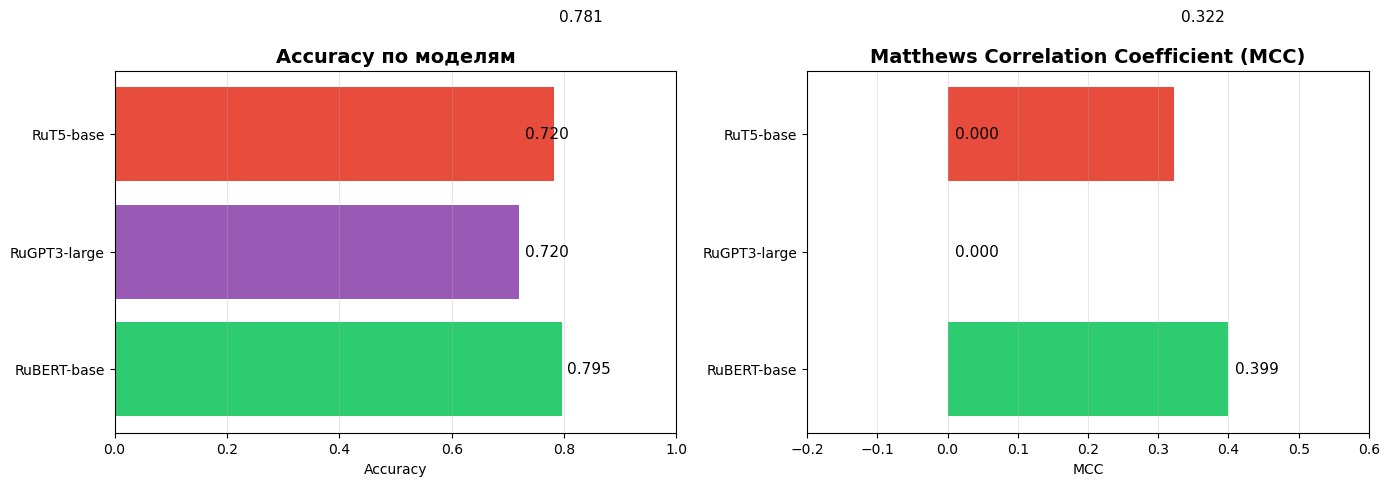


ЗАВИСИМОСТЬ КАЧЕСТВА RuGPT3 ОТ КОЛИЧЕСТВА FEW-SHOT ПРИМЕРОВ


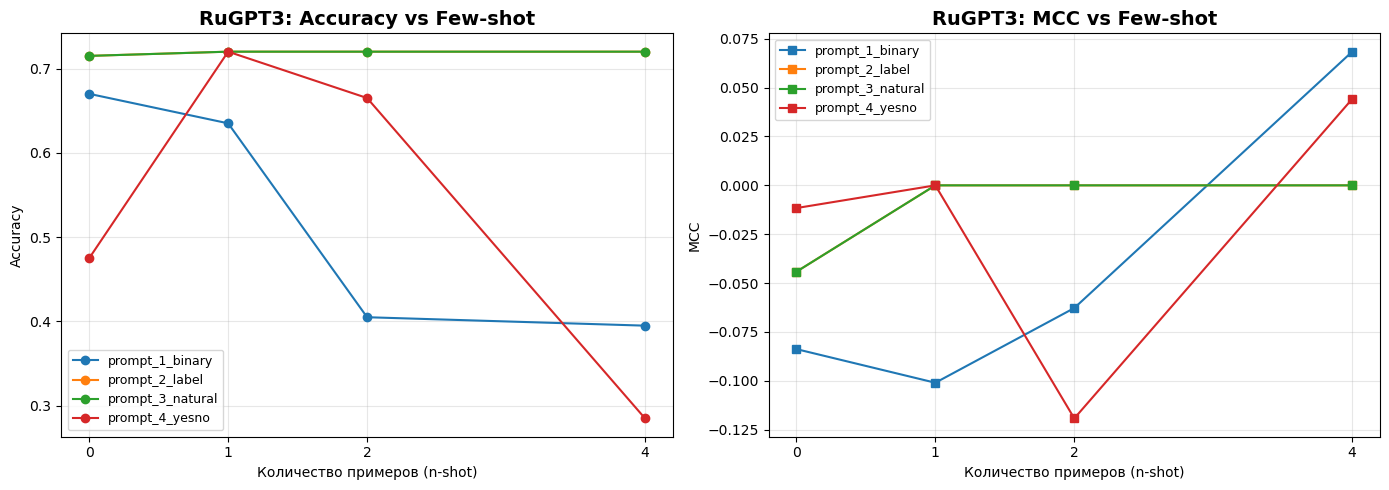

Итоговая таблица сохранена в results/final_comparison.csv


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

rubert_accuracy = 0.7955  # eval_accuracy из trainer.evaluate(test_encoded)
rubert_mcc = 0.3991       # eval_mcc из trainer.evaluate(test_encoded)

gpt3_zero_shot_best_acc = 0.720   # prompt_2_label, prompt_3_natural при n_shot=0
gpt3_zero_shot_best_mcc = 0.000
gpt3_few_shot_best_acc = 0.720    # prompt_2_label при n_shot=1,2,4
gpt3_few_shot_best_mcc = 0.000

# RuT5
try:
    rut5_accuracy = rut5_test_accuracy
    rut5_mcc = rut5_test_mcc
except NameError:
    rut5_accuracy = None
    rut5_mcc = None
    print("RuT5 ещё не обучен")

# Сводная таблица
results = {
    "Модель": [
        "RuBERT-base (fine-tune)",
        "RuGPT3-large (zero-shot, лучший)",
        "RuGPT3-large (few-shot, лучший)",
        "RuT5-base (fine-tune)",
    ],
    "Подход": [
        "Классификация [CLS]",
        "Генерация да/нет",
        "Генерация да/нет + примеры",
        "Seq2seq: yes/no",
    ],
    "Accuracy": [
        rubert_accuracy,
        gpt3_zero_shot_best_acc,
        gpt3_few_shot_best_acc,
        rut5_accuracy,
    ],
    "MCC": [
        rubert_mcc,
        gpt3_zero_shot_best_mcc,
        gpt3_few_shot_best_mcc,
        rut5_mcc,
    ],
}

df = pd.DataFrame(results)

print("=" * 80)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ НА ДАТАСЕТЕ RuCoLA (in_domain_dev)")
print("=" * 80)
print(df.to_string(index=False))
print("\n" + "=" * 80)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Фильтруем модели с валидными метриками
valid_mask = df["Accuracy"].notna()
df_valid = df[valid_mask].copy()
models = df_valid["Модель"].str.replace(r" \(.*\)", "", regex=True)
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c'][:len(df_valid)]

# Accuracy
axes[0].barh(models, df_valid["Accuracy"], color=colors)
axes[0].set_title("Accuracy по моделям", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Accuracy")
axes[0].set_xlim(0, 1.0)
for i, v in enumerate(df_valid["Accuracy"]):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

# MCC
axes[1].barh(models, df_valid["MCC"], color=colors)
axes[1].set_title("Matthews Correlation Coefficient (MCC)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("MCC")
axes[1].set_xlim(-0.2, 0.6)
for i, v in enumerate(df_valid["MCC"]):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("results/comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Детальный анализ RuGPT3 по промптам
print("\n" + "=" * 80)
print("ЗАВИСИМОСТЬ КАЧЕСТВА RuGPT3 ОТ КОЛИЧЕСТВА FEW-SHOT ПРИМЕРОВ")
print("=" * 80)

try:
    gpt3_results = pd.read_csv("results/gpt3_fewshot_results.csv")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for prompt_name in gpt3_results["prompt"].unique():
        subset = gpt3_results[gpt3_results["prompt"] == prompt_name]
        axes[0].plot(subset["n_shot"], subset["accuracy"], marker="o", label=prompt_name)
        axes[1].plot(subset["n_shot"], subset["mcc"], marker="s", label=prompt_name)
    
    axes[0].set_title("RuGPT3: Accuracy vs Few-shot", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Количество примеров (n-shot)")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks([0, 1, 2, 4])
    
    axes[1].set_title("RuGPT3: MCC vs Few-shot", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Количество примеров (n-shot)")
    axes[1].set_ylabel("MCC")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks([0, 1, 2, 4])
    
    plt.tight_layout()
    plt.savefig("results/gpt3_detailed.png", dpi=150, bbox_inches='tight')
    plt.show()
except FileNotFoundError:
    print("Файл results/gpt3_fewshot_results.csv не найден")

# ── Сохранение итоговой таблицы ──────────────────────────────
df.to_csv("results/final_comparison.csv", index=False)
print("Итоговая таблица сохранена в results/final_comparison.csv")

# Выводы

Fine-tuned модели значительно превосходят few-shot подход.

По Accuracy:

RuBERT-base: 0.795 (лучший результат)

RuT5-base: 0.781

RuGPT3-large: 0.720

По MCC (Matthews Correlation Coefficient):

RuBERT-base: 0.399 (лучший результат)

RuT5-base: 0.322

RuGPT3-large: 0.000